#### Example running SpaFHy with jupyter notebook for Pallas catchment(s)

In [1]:
import os
from model_driver import parallel_driver
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()
io_path = str(Path(os.getenv('PROJECT_FOLDER'))) # PROJECT_FOLDER=.... from .env file


In [2]:
# example how to run single catchment or multiple catchments in parallel
catchment = 'pallas'
run_multiple = False # run multiple catchments in parallel

if run_multiple: # running multiple catchments as in catchment_no
    catchment_no = np.arange(2,13,1) # catchment_no from 2 to 12
else:
    catchment_no = 2 # running only catchment_no 2 (= lompolonjängänoja)

folder = os.path.join(io_path, catchment) # io repo

outputfile = parallel_driver(catchment, catchment_no, create_ncf=True, create_spinup=False, output=True, folder=folder)

# Reading the .nc results file that was just created
results = xr.open_dataset(outputfile[0])

*** Catchment no.: 2 ***
*** State variables assigned from parameters.py ***
*** Running model ***
*** TOPMODEL run
*** Bucket organic layer drains according to Campbell 1985
[0.01  0.025   nan]
Running timestep:  1
Running timestep:  2
Running timestep:  3
Running timestep:  4
Running timestep:  5
Running timestep:  6
Running timestep:  7
Running timestep:  8
Running timestep:  9
Running timestep:  10
Running timestep:  11
Running timestep:  12
Running timestep:  13
Running timestep:  14
Running timestep:  15
Running timestep:  16
Running timestep:  17
Running timestep:  18
Running timestep:  19
Running timestep:  20
Running timestep:  21
Running timestep:  22
Running timestep:  23
Running timestep:  24
Running timestep:  25
Running timestep:  26
Running timestep:  27
Running timestep:  28
Running timestep:  29
Running timestep:  30


/Users/jpnousu/Models/SpaFHy_v2.0/bucketgrid.py:280: RuntimeWarning: invalid value encountered in power
  Psi = -1 / self.alpha_root*(s**(1.0 / m) - 1.0)**(1.0 / n)  # alpha defines the unit (kPa)


Running timestep:  31
Running timestep:  32
Running timestep:  33
Running timestep:  34
Running timestep:  35
Running timestep:  36
Running timestep:  37
Running timestep:  38
Running timestep:  39
Running timestep:  40
Running timestep:  41
Running timestep:  42
Running timestep:  43
Running timestep:  44
Running timestep:  45
Running timestep:  46
Running timestep:  47
Running timestep:  48
Running timestep:  49
Running timestep:  50
Running timestep:  51
Running timestep:  52
Running timestep:  53
Running timestep:  54
Running timestep:  55
Running timestep:  56
Running timestep:  57
Running timestep:  58
Running timestep:  59
Running timestep:  60
Running timestep:  61
Running timestep:  62
Running timestep:  63
Running timestep:  64
Running timestep:  65
Running timestep:  66
Running timestep:  67
Running timestep:  68
Running timestep:  69
Running timestep:  70
Running timestep:  71
Running timestep:  72
Running timestep:  73
Running timestep:  74
Running timestep:  75
Running ti

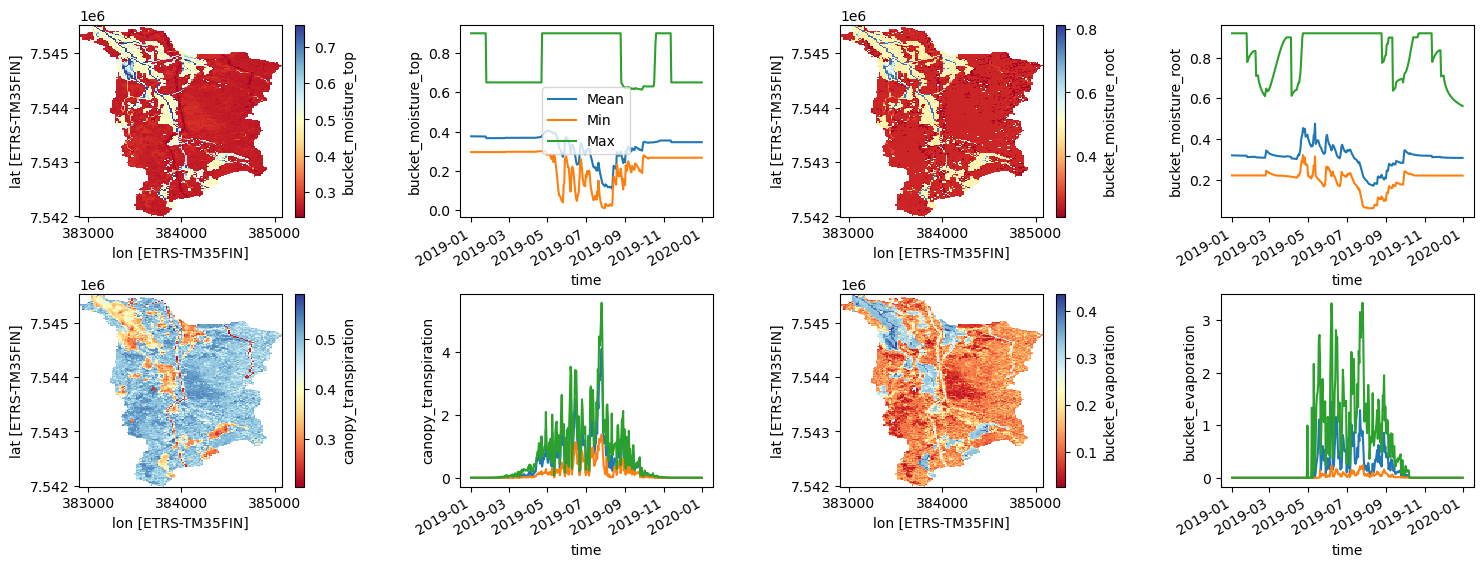

In [3]:
# example plot 1 (works for 1D, TOP, or 2D simulation)
fig, axes = plt.subplots(2, 4, figsize=(18, 6))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to easily index 0–7

# Plot 1
results['bucket_moisture_top'].mean(dim='time').plot(ax=axes[0], cmap='RdYlBu')

# Plot 2
results['bucket_moisture_top'].mean(dim=['lat', 'lon']).plot(ax=axes[1], label='Mean')
results['bucket_moisture_top'].min(dim=['lat', 'lon']).plot(ax=axes[1], label='Min')
results['bucket_moisture_top'].max(dim=['lat', 'lon']).plot(ax=axes[1], label='Max')
axes[1].legend()
# Plot 3
results['bucket_moisture_root'].mean(dim='time').plot(ax=axes[2], cmap='RdYlBu')

# Plot 4
results['bucket_moisture_root'].mean(dim=['lat', 'lon']).plot(ax=axes[3], label='Mean')
results['bucket_moisture_root'].min(dim=['lat', 'lon']).plot(ax=axes[3], label='Min')
results['bucket_moisture_root'].max(dim=['lat', 'lon']).plot(ax=axes[3], label='Max')

# Plot 5
results['canopy_transpiration'].mean(dim='time').plot(ax=axes[4], cmap='RdYlBu')

# Plot 6
results['canopy_transpiration'].mean(dim=['lat', 'lon']).plot(ax=axes[5], label='Mean')
results['canopy_transpiration'].min(dim=['lat', 'lon']).plot(ax=axes[5], label='Min')
results['canopy_transpiration'].max(dim=['lat', 'lon']).plot(ax=axes[5], label='Max')

# Plot 7
results['bucket_evaporation'].mean(dim='time').plot(ax=axes[6], cmap='RdYlBu')

# Plot 8
results['bucket_evaporation'].mean(dim=['lat', 'lon']).plot(ax=axes[7], label='Mean')
results['bucket_evaporation'].min(dim=['lat', 'lon']).plot(ax=axes[7], label='Min')
results['bucket_evaporation'].max(dim=['lat', 'lon']).plot(ax=axes[7], label='Max')

# Plot 8
#results['parameters_streams'].plot(ax=axes[7])

plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Adjust spacing between plots

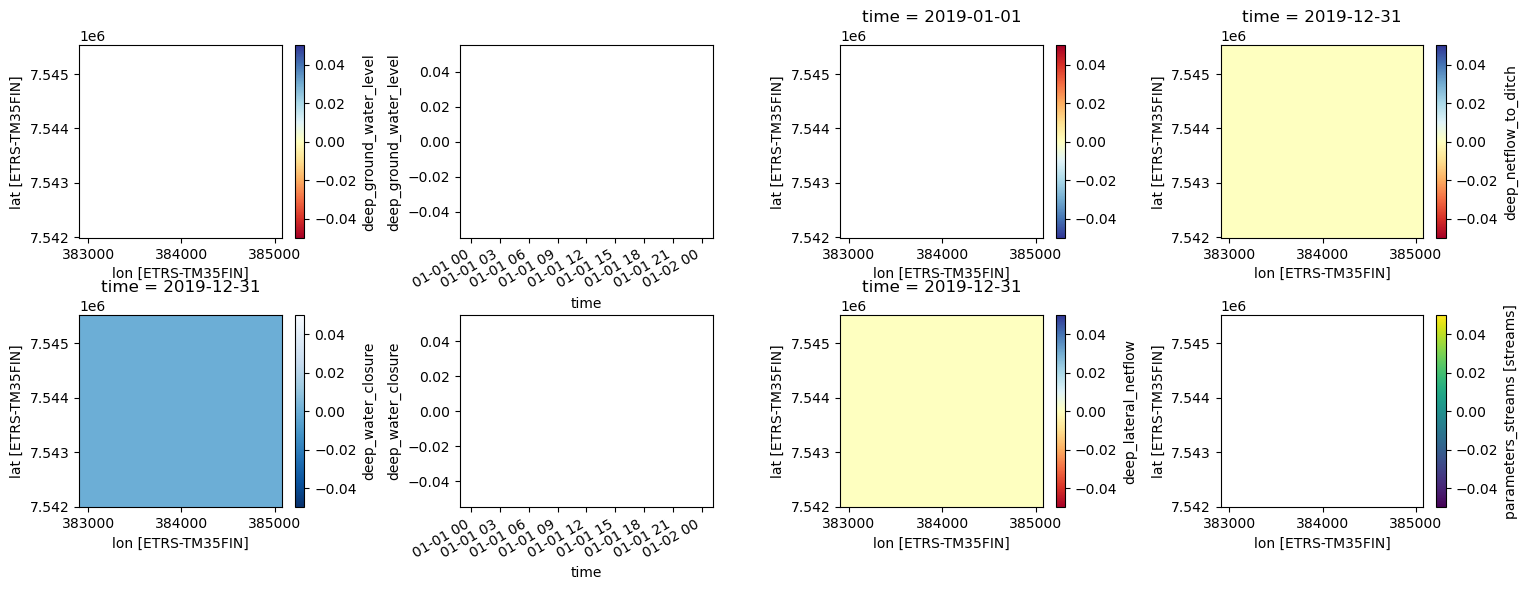

In [4]:
# example plot 2 (works only for 2D simulation)

fig, axes = plt.subplots(2, 4, figsize=(18, 6))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to easily index 0–7

# Plot 1
results['deep_ground_water_level'].mean(dim='time').plot(ax=axes[0], cmap='RdYlBu')

# Plot 3
results['deep_ground_water_level'].mean(dim=['lat', 'lon']).plot(ax=axes[1], label='Mean')
results['deep_ground_water_level'].min(dim=['lat', 'lon']).plot(ax=axes[1], label='Min')
results['deep_ground_water_level'].max(dim=['lat', 'lon']).plot(ax=axes[1], label='Max')

# Plot 2
(results['parameters_elevation'] - results['deep_ground_water_level'][0]).plot(ax=axes[2], cmap='RdYlBu_r')

# Plot 4
#results['deep_netflow_to_ditch'][0].plot(ax=axes[3])
results['deep_netflow_to_ditch'].cumsum(dim='time')[-1].plot(ax=axes[3], cmap='RdYlBu')

# Plot 5
#results['deep_water_closure'][-1].plot(ax=axes[4])
results['deep_water_closure'].cumsum(dim='time')[-1].plot(ax=axes[4], cmap='Blues_r')

# Plot 6
results['deep_water_closure'].mean(dim=['lat', 'lon']).plot(ax=axes[5], label='Mean')
results['deep_water_closure'].min(dim=['lat', 'lon']).plot(ax=axes[5], label='Min')
results['deep_water_closure'].max(dim=['lat', 'lon']).plot(ax=axes[5], label='Max')

# Plot 7
#results['deep_lateral_netflow'].min(dim='time').plot(ax=axes[6])
results['deep_lateral_netflow'].cumsum(dim='time')[-1].plot(ax=axes[6], cmap='RdYlBu')

# Plot 8
results['parameters_streams'].plot(ax=axes[7])

plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Adjust spacing between plots

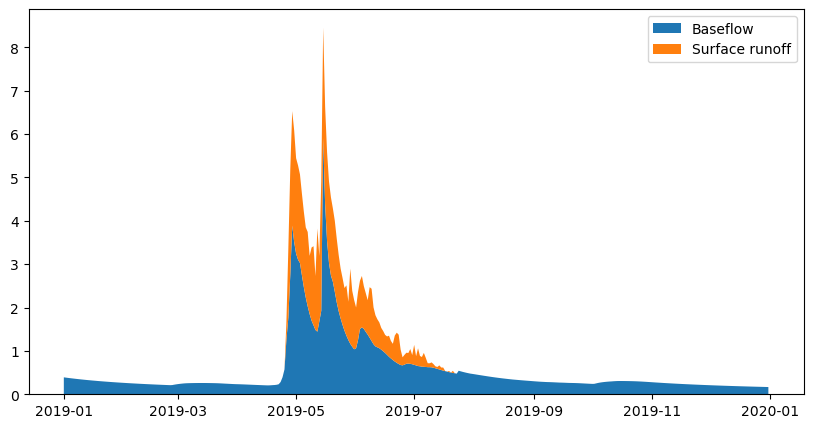

In [3]:
import matplotlib.pyplot as plt

baseflow = results['top_baseflow']
runoff = results['bucket_surface_runoff'].mean(dim=['lat','lon'])

time = baseflow['time']

plt.figure(figsize=(10,5))
plt.stackplot(
    time,
    baseflow,
    runoff,
    labels=['Baseflow', 'Surface runoff']
)
plt.legend()

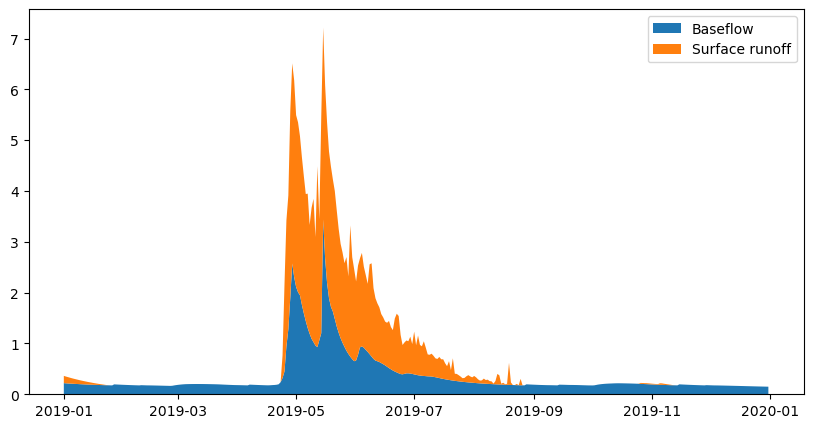

In [3]:
import matplotlib.pyplot as plt

baseflow = results['top_baseflow']
runoff = results['bucket_surface_runoff'].mean(dim=['lat','lon'])

time = baseflow['time']

plt.figure(figsize=(10,5))
plt.stackplot(
    time,
    baseflow,
    runoff,
    labels=['Baseflow', 'Surface runoff']
)
plt.legend()

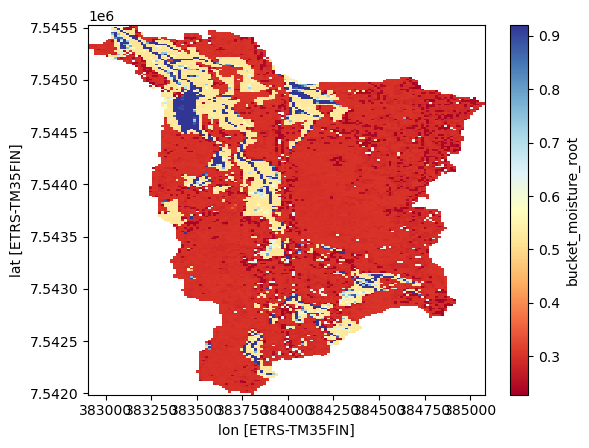

In [19]:
#results['top_local_saturation_deficit'].sel(time=slice('2019-05-01', '2019-06-01')).mean(dim='time').plot(vmax=1, cmap='RdYlBu')
results['bucket_moisture_root'].sel(time=slice('2019-05-01', '2019-06-20')).mean(dim='time').plot(cmap='RdYlBu')

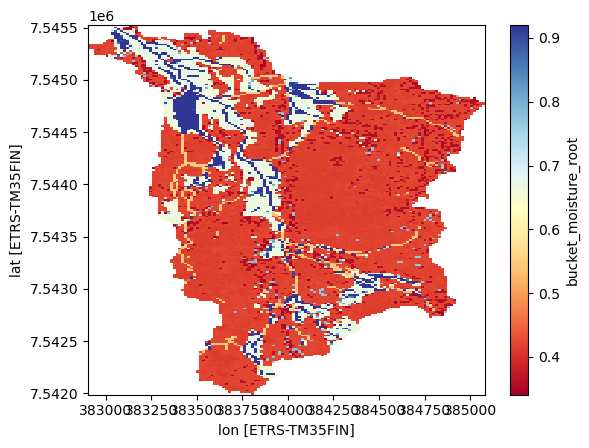

In [4]:
results['bucket_moisture_root'].max(dim='time').plot(cmap='RdYlBu')

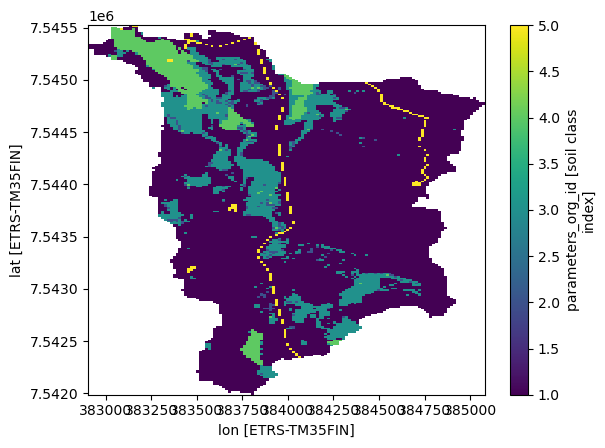

In [5]:
results['parameters_org_id'].plot()

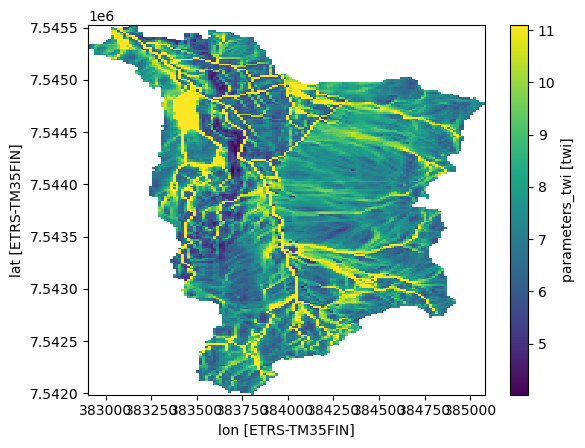

In [5]:
results['parameters_twi'].plot()

(array([  18.,   50.,  103.,  231.,  450.,  883., 1319., 1661., 1803.,
        1775., 1498., 1253., 1021.,  774.,  667.,  466.,  382.,  305.,
         250., 1447.]),
 array([ 4.02087831,  4.37470627,  4.72853374,  5.0823617 ,  5.43618965,
         5.79001713,  6.14384508,  6.49767303,  6.85150051,  7.20532846,
         7.55915642,  7.91298389,  8.26681137,  8.6206398 ,  8.97446728,
         9.32829475,  9.68212318, 10.03595066, 10.38977814, 10.74360657,
        11.09743404]),
 <BarContainer object of 20 artists>)

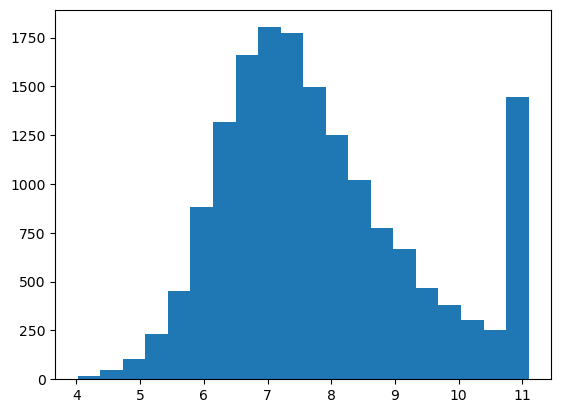

In [4]:
plt.hist(results['parameters_twi'].data.flatten(), bins=20)